# From AI Ranking to Wet-Lab Validation

**v0.1 educational notebook**

## Goal
Connect computational ranking to simulated wet-lab evidence: surface binding, internalization, lysosomal trafficking, and ADC killing.

> **SIMULATED WET-LAB RESULTS:** All assay values in this notebook are synthetic and exist only to demonstrate the closed-loop data workflow.

## Canonical guide

### Learning objectives
- Represent binding, internalization, lysosomal trafficking, and killing as experimental evidence.
- Keep “not tested” distinct from a measured low value.
- Update the feature matrix with functional evidence and provenance.

### Data mode
All wet-lab values are simulated for education; no experimental measurements are included.

### Inputs
`outputs/adc_pu_ranking_v01.csv`, `outputs/adc_experimental_batch_001.csv`

### Canonical outputs
`outputs/adc_experimental_results_001.csv`, `outputs/adc_experiment_metadata_001.csv`, `outputs/adc_target_feature_matrix_v02.csv`

### Scientific limitation
The equations generating assay values are synthetic and must not be interpreted as ADC mechanism models or empirical effect sizes.

### Next step
Notebook 09 uses the simulated functional outcomes to demonstrate active learning.


In [1]:
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA = ROOT / 'data'
OUTPUTS = ROOT / 'outputs'
OUTPUTS.mkdir(exist_ok=True)
print('ROOT:', ROOT.resolve())

ROOT: /mnt/data/audit_adc/adc-scientific-ai


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
rng=np.random.default_rng(44)
pu=pd.read_csv(OUTPUTS/'adc_pu_ranking_v01.csv',index_col=0)
batch=pd.read_csv(OUTPUTS/'adc_experimental_batch_001.csv',index_col=0)
base=batch.bagging_pu_score.clip(0,1); n=len(batch)
binding=np.clip(.65*base+.35*rng.random(n),0,1)
internal=np.clip(.40*base+.25*binding+.35*rng.random(n),0,1)
lysosome=np.clip(.55*internal+.45*rng.random(n),0,1)
killing=np.clip(.20*binding+.30*internal+.30*lysosome+.20*rng.random(n),0,1)
res=pd.DataFrame({'binding_score':binding,'internalization_score':internal,'lysosome_score':lysosome,'adc_killing_score':killing},index=batch.index)
res['selection_strategy']=batch.selection_strategy
res['pre_experiment_pu_score']=batch.bagging_pu_score
res['pre_experiment_uncertainty']=batch.bagging_pu_uncertainty
res['functional_adc_score']=.20*res.binding_score+.25*res.internalization_score+.25*res.lysosome_score+.30*res.adc_killing_score
res['functional_positive']=(res.functional_adc_score>=.70).astype(int)
res['label_source']='SIMULATED_WET_LAB_V01'; res['experiment_batch']='ADC_BATCH_001'
res.sort_values('functional_adc_score',ascending=False)

,binding_score,internalization_score,lysosome_score,adc_killing_score,selection_strategy,pre_experiment_pu_score,pre_experiment_uncertainty,functional_adc_score,functional_positive,label_source,experiment_batch
gene_symbol,,,,,,,,,,,
FOLR1,0.665332,0.638461,0.768190,0.594494,EXPLOITATION,0.884603,0.029510,0.663077,0,SIMULATED_WET_LAB_V01,ADC_BATCH_001
NECTIN4,0.642120,0.586348,0.745330,0.632700,EXPLOITATION,0.921881,0.021809,0.651154,0,SIMULATED_WET_LAB_V01,ADC_BATCH_001
GENE_A,0.419736,0.322576,0.582756,0.464788,EXPLORATION,0.184128,0.044254,0.449717,0,SIMULATED_WET_LAB_V01,ADC_BATCH_001
GENE_R,0.193004,0.466290,0.615289,0.380523,EXPLORATION,0.209528,0.047970,0.423152,0,SIMULATED_WET_LAB_V01,ADC_BATCH_001
EPCAM,0.509351,0.447824,0.255061,0.481815,EXPLORATION,0.261748,0.059973,0.422136,0,SIMULATED_WET_LAB_V01,ADC_BATCH_001
GENE_G,0.275719,0.388409,0.535632,0.368515,EXPLORATION,0.205692,0.074702,0.396709,0,SIMULATED_WET_LAB_V01,ADC_BATCH_001


In [3]:
for c in ['binding_score','internalization_score','lysosome_score','adc_killing_score']:
    rho=spearmanr(res.pre_experiment_pu_score,res[c]).statistic; print(c,round(rho,3))
res.to_csv(OUTPUTS/'adc_experimental_results_001.csv')
meta=pd.DataFrame([{'experiment_batch':'ADC_BATCH_001','model_version':'PU_V01','feature_matrix_version':'V01','data_type':'SIMULATED','selection_strategy':'exploitation + exploration'}])
meta.to_csv(OUTPUTS/'adc_experiment_metadata_001.csv',index=False)

binding_score 0.714
internalization_score 0.886
lysosome_score 0.543
adc_killing_score 0.829


In [4]:
fm=pd.read_csv(OUTPUTS/'adc_target_feature_matrix_v01.csv',index_col=0)
cols=['binding_score','internalization_score','lysosome_score','adc_killing_score','functional_adc_score','functional_positive']
fm2=fm.join(res[cols],how='left'); fm2['has_experimental_data']=fm2.functional_adc_score.notna(); fm2.to_csv(OUTPUTS/'adc_target_feature_matrix_v02.csv')
print('tested:',fm2.has_experimental_data.sum(),'untested:',(~fm2.has_experimental_data).sum())

tested: 6 untested: 18


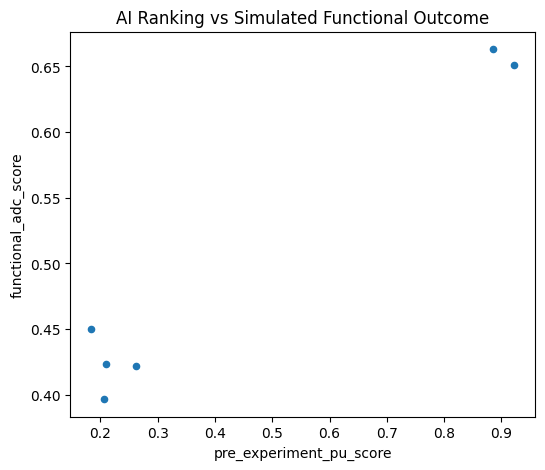

In [5]:
res.plot.scatter(x='pre_experiment_pu_score',y='functional_adc_score',figsize=(6,5),title='AI Ranking vs Simulated Functional Outcome')
plt.show()

## Key distinction
`NaN` means “not tested”; zero means “tested and low.” Keeping this distinction is essential for subsequent active learning. The experimental outcome is also qualitatively different from a literature-derived known-target label and should retain its provenance.